<a href="https://colab.research.google.com/github/Vitoro42/TelecomX_LATAM_Parte2/blob/main/TelecomX_LATAM_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 **EXTRACCIÓN**

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('/content/datos_tratados.csv')
df.head()

,id,Churn,genero,adulto_mayor,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [11]:
df.columns

Index(['id', 'Churn', 'genero', 'adulto_mayor', 'posee_pareja',
       'posee_dependientes', 'tiempo_contrato', 'servicio_telefono',
       'multiples_lineas', 'tipo_internet', 'seguridad_online',
       'backup_online', 'proteccion_dispositivo', 'soporte_tecnico',
       'streaming_tv', 'streaming_peliculas', 'tipo_contrato',
       'factura_digital', 'metodo_pago', 'valor_mensual', 'total_cobrado',
       'cuentas_diarias'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7032 non-null   object 
 1   Churn                   7032 non-null   object 
 2   genero                  7032 non-null   object 
 3   adulto_mayor            7032 non-null   int64  
 4   posee_pareja            7032 non-null   object 
 5   posee_dependientes      7032 non-null   object 
 6   tiempo_contrato         7032 non-null   int64  
 7   servicio_telefono       7032 non-null   object 
 8   multiples_lineas        7032 non-null   object 
 9   tipo_internet           7032 non-null   object 
 10  seguridad_online        7032 non-null   object 
 11  backup_online           7032 non-null   object 
 12  proteccion_dispositivo  7032 non-null   object 
 13  soporte_tecnico         7032 non-null   object 
 14  streaming_tv            7032 non-null   

# **Procesamiento de datos**

In [25]:
# Borramos la columna 'id' ya que no aporta información para realizar predicciones.

df = df.drop(columns=['id'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Churn                   7032 non-null   object 
 1   genero                  7032 non-null   object 
 2   adulto_mayor            7032 non-null   int64  
 3   posee_pareja            7032 non-null   object 
 4   posee_dependientes      7032 non-null   object 
 5   tiempo_contrato         7032 non-null   int64  
 6   servicio_telefono       7032 non-null   object 
 7   multiples_lineas        7032 non-null   object 
 8   tipo_internet           7032 non-null   object 
 9   seguridad_online        7032 non-null   object 
 10  backup_online           7032 non-null   object 
 11  proteccion_dispositivo  7032 non-null   object 
 12  soporte_tecnico         7032 non-null   object 
 13  streaming_tv            7032 non-null   object 
 14  streaming_peliculas     7032 non-null   

## **Verificación de la Proporción de Cancelación (Churn)**


Conteo de clases:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Proporción porcentual:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


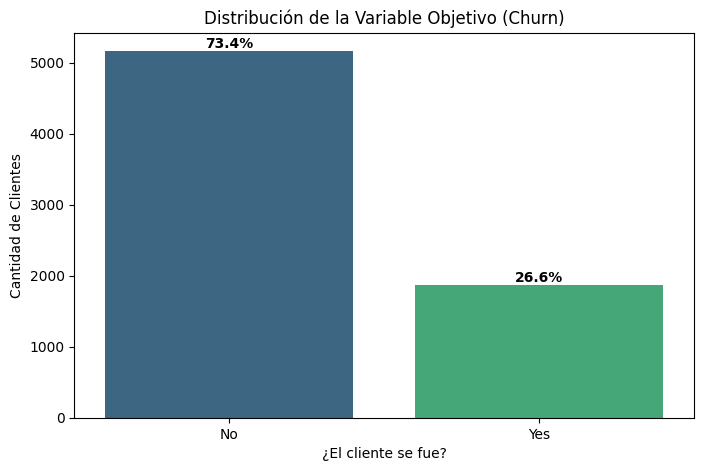

In [15]:
# 1. Conteo absoluto y porcentual
conteo = df['Churn'].value_counts()
proporcion = df['Churn'].value_counts(normalize=True) * 100

print(f"Conteo de clases:\n{conteo}")
print(f"\nProporción porcentual:\n{proporcion}")

# 2. Visualización del desbalance
plt.figure(figsize=(8, 5))
sns.barplot(x=conteo.index, y=conteo.values, palette='viridis', hue=conteo.index, legend=False)

plt.title('Distribución de la Variable Objetivo (Churn)')
plt.xlabel('¿El cliente se fue?')
plt.ylabel('Cantidad de Clientes')

# Añadir etiquetas de porcentaje sobre las barras
for i, valor in enumerate(conteo.values):
    pct = f'{proporcion.values[i]:.1f}%'
    plt.text(i, valor + 50, pct, ha='center', fontweight='bold')

plt.show()

## **Encoding**

In [32]:
# Simplificación de categorías (Pasar de 3 opciones a solo 2: Yes/No)

from sklearn.preprocessing import LabelEncoder

cols_a_simplificar = [
    'seguridad_online', 'backup_online', 'proteccion_dispositivo',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'multiples_lineas'
]

for col in cols_a_simplificar:
    # Reemplazamos tanto "No internet service" como "No phone service" por "No"
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Aplicar Label Encoding (Convertir palabras a 0 y 1)
le = LabelEncoder()

# Seleccionamos todas las columnas que son de tipo texto (object)
columnas_texto = df.select_dtypes(include=['object']).columns

for col in columnas_texto:
    df[col] = le.fit_transform(df[col])

# Resultado final
print("✅ Dataset transformado exitosamente.")
print(f"Estructura final: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

✅ Dataset transformado exitosamente.
Estructura final: 7032 filas y 21 columnas.


,Churn,genero,adulto_mayor,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,0,0,0,1,1,9,1,0,0,0,...,0,1,1,0,1,1,3,65.6,593.30,2.186667
1,0,1,0,0,0,9,1,1,0,0,...,0,0,0,1,0,0,3,59.9,542.40,1.996667
2,1,1,0,0,0,4,1,0,1,0,...,1,0,0,0,0,1,2,73.9,280.85,2.463333
3,1,1,1,1,0,13,1,0,1,0,...,1,0,1,1,0,1,2,98.0,1237.85,3.266667
4,1,0,1,1,0,3,1,0,1,0,...,0,1,1,0,0,1,3,83.9,267.40,2.796667


## **Análisis de Correlación**

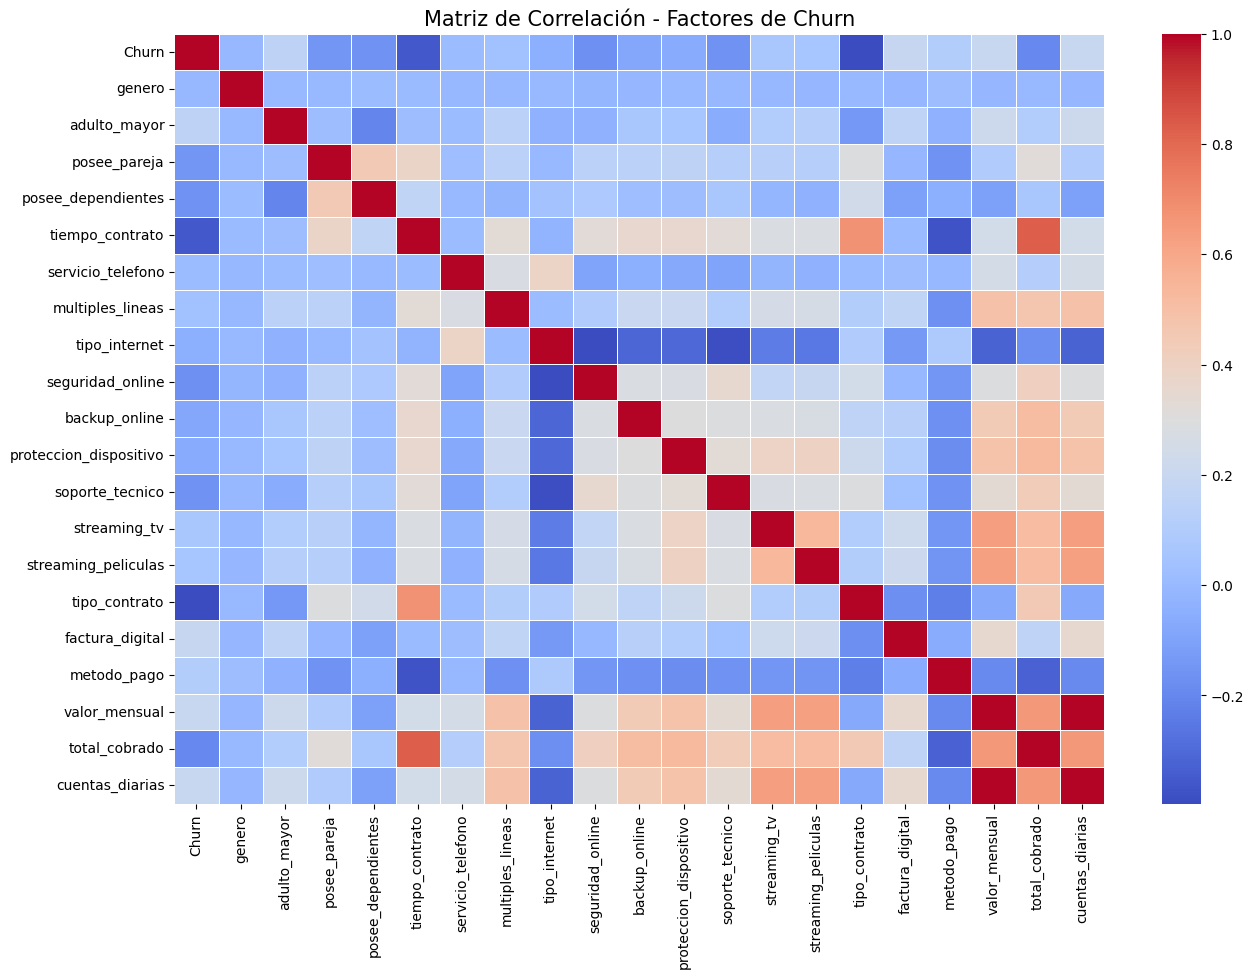

--- Variables con Mayor Impacto en el Churn ---
Churn                     1.000000
cuentas_diarias           0.192858
valor_mensual             0.192858
factura_digital           0.191454
adulto_mayor              0.150541
metodo_pago               0.107852
streaming_tv              0.063254
streaming_peliculas       0.060860
multiples_lineas          0.040033
servicio_telefono         0.011691
genero                   -0.008545
tipo_internet            -0.047097
proteccion_dispositivo   -0.066193
backup_online            -0.082307
posee_pareja             -0.149982
posee_dependientes       -0.163128
soporte_tecnico          -0.164716
seguridad_online         -0.171270
total_cobrado            -0.199484
tiempo_contrato          -0.354049
tipo_contrato            -0.396150
Name: Churn, dtype: float64


In [35]:
# 1. Calculamos la matriz de correlación
# Usamos el método de Pearson (por defecto)
corr_matrix = df.corr()

# 2. Creamos el Mapa de Calor para una visión general
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación - Factores de Churn', fontsize=15)
plt.show()

# 3. Enfocarnos específicamente en la relación con 'Churn'
# Ordenamos de mayor a menor influencia
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

print("--- Variables con Mayor Impacto en el Churn ---")
print(churn_corr)

## **Análisis Dirigido**

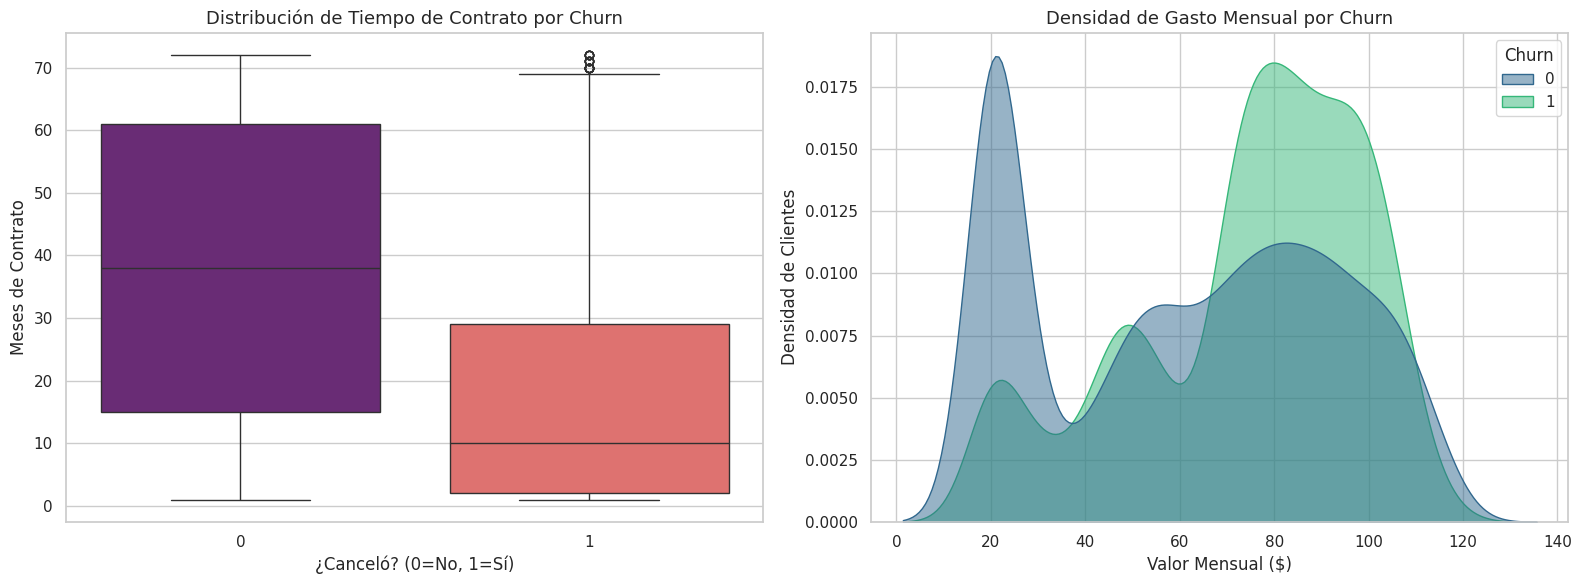

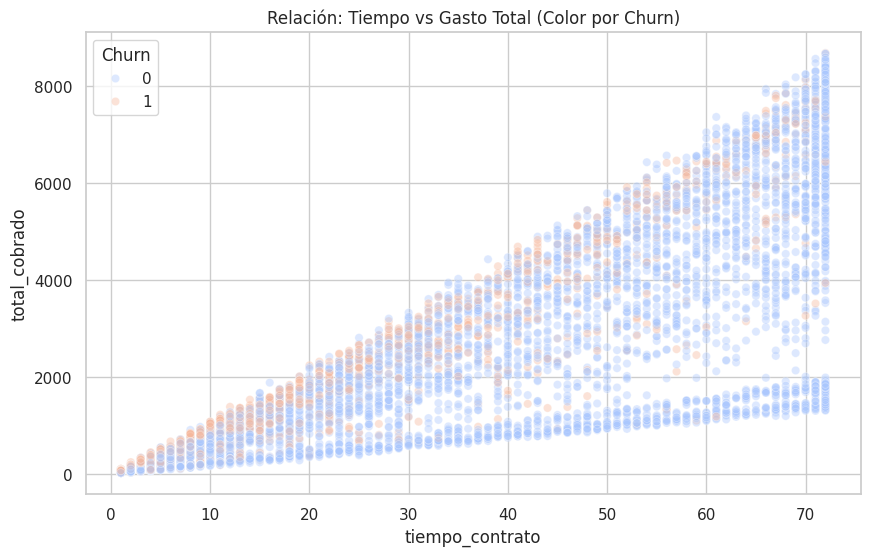

In [36]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Tiempo de Contrato vs Cancelación (Boxplot)
# El boxplot nos dirá la mediana de meses de los que se van vs los que se quedan
sns.boxplot(ax=axes[0], x='Churn', y='tiempo_contrato', data=df, palette='magma', hue='Churn', legend=False)
axes[0].set_title('Distribución de Tiempo de Contrato por Churn', fontsize=13)
axes[0].set_xlabel('¿Canceló? (0=No, 1=Sí)')
axes[0].set_ylabel('Meses de Contrato')

# 2. Gasto Mensual vs Cancelación (KDE Plot / Histograma)
# Esto nos permite ver en qué rangos de precio hay más "fugas" de clientes
sns.kdeplot(ax=axes[1], data=df, x='valor_mensual', hue='Churn', fill=True, common_norm=False, palette='viridis', alpha=.5)
axes[1].set_title('Densidad de Gasto Mensual por Churn', fontsize=13)
axes[1].set_xlabel('Valor Mensual ($)')
axes[1].set_ylabel('Densidad de Clientes')

plt.tight_layout()
plt.show()

# 3. Relación Gasto Total vs Tiempo (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tiempo_contrato', y='total_cobrado', hue='Churn', alpha=0.4, palette='coolwarm')
plt.title('Relación: Tiempo vs Gasto Total (Color por Churn)')
plt.show()

## **Separación de Datos (Train/Test Split)**

In [37]:
from sklearn.model_selection import train_test_split

# Definimos nuestras variables de entrada (X) y la variable objetivo (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# Dividimos: 70% para aprender (entrenamiento) y 30% para el examen final (prueba)
# Usamos stratify=y para mantener la proporción de 26% de Churn en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"✅ Datos separados:")
print(f"- Entrenamiento: {X_train.shape[0]} registros")
print(f"- Prueba: {X_test.shape[0]} registros")

✅ Datos separados:
- Entrenamiento: 4922 registros
- Prueba: 2110 registros


## **Creación de Modelos**

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix

# --- MODELO A: Regresión Logística (Requiere Normalización) ---
# Creamos un "túnel" que primero escala y luego entrena
modelo_logistico = make_pipeline(StandardScaler(), LogisticRegression())
modelo_logistico.fit(X_train, y_train)

# --- MODELO B: Random Forest (NO requiere Normalización) ---
modelo_forest = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_forest.fit(X_train, y_train)

print("✅ ¡Modelos entrenados exitosamente!")

✅ ¡Modelos entrenados exitosamente!


##  **Evaluación de Modelos**


--- Reporte: Regresión Logística ---
Accuracy:  0.8000
Precision: 0.6514
Recall:    0.5330
F1-Score:  0.5863


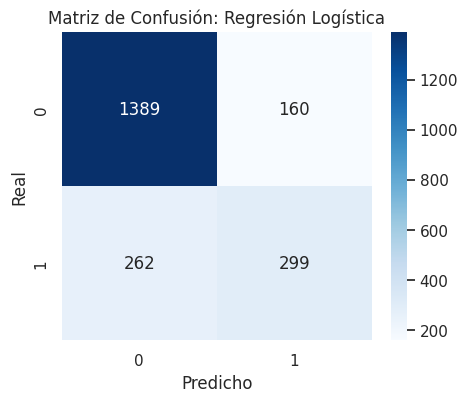


--- Reporte: Random Forest ---
Accuracy:  0.7820
Precision: 0.6150
Recall:    0.4813
F1-Score:  0.5400


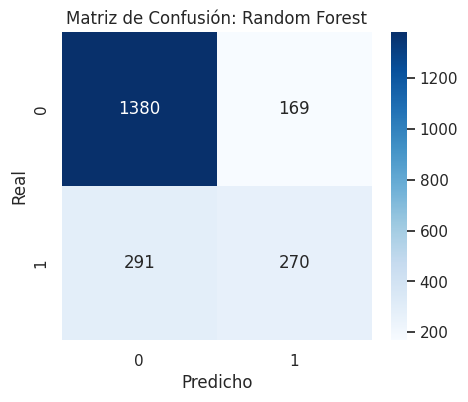

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluar_modelo(modelo, name, X_test, y_test):
    y_pred = modelo.predict(X_test)

    # Cálculo de métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n--- Reporte: {name} ---")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión: {name}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

# Evaluamos ambos modelos
evaluar_modelo(modelo_logistico, "Regresión Logística", X_test, y_test)
evaluar_modelo(modelo_forest, "Random Forest", X_test, y_test)

## **Importancia de las Variables**

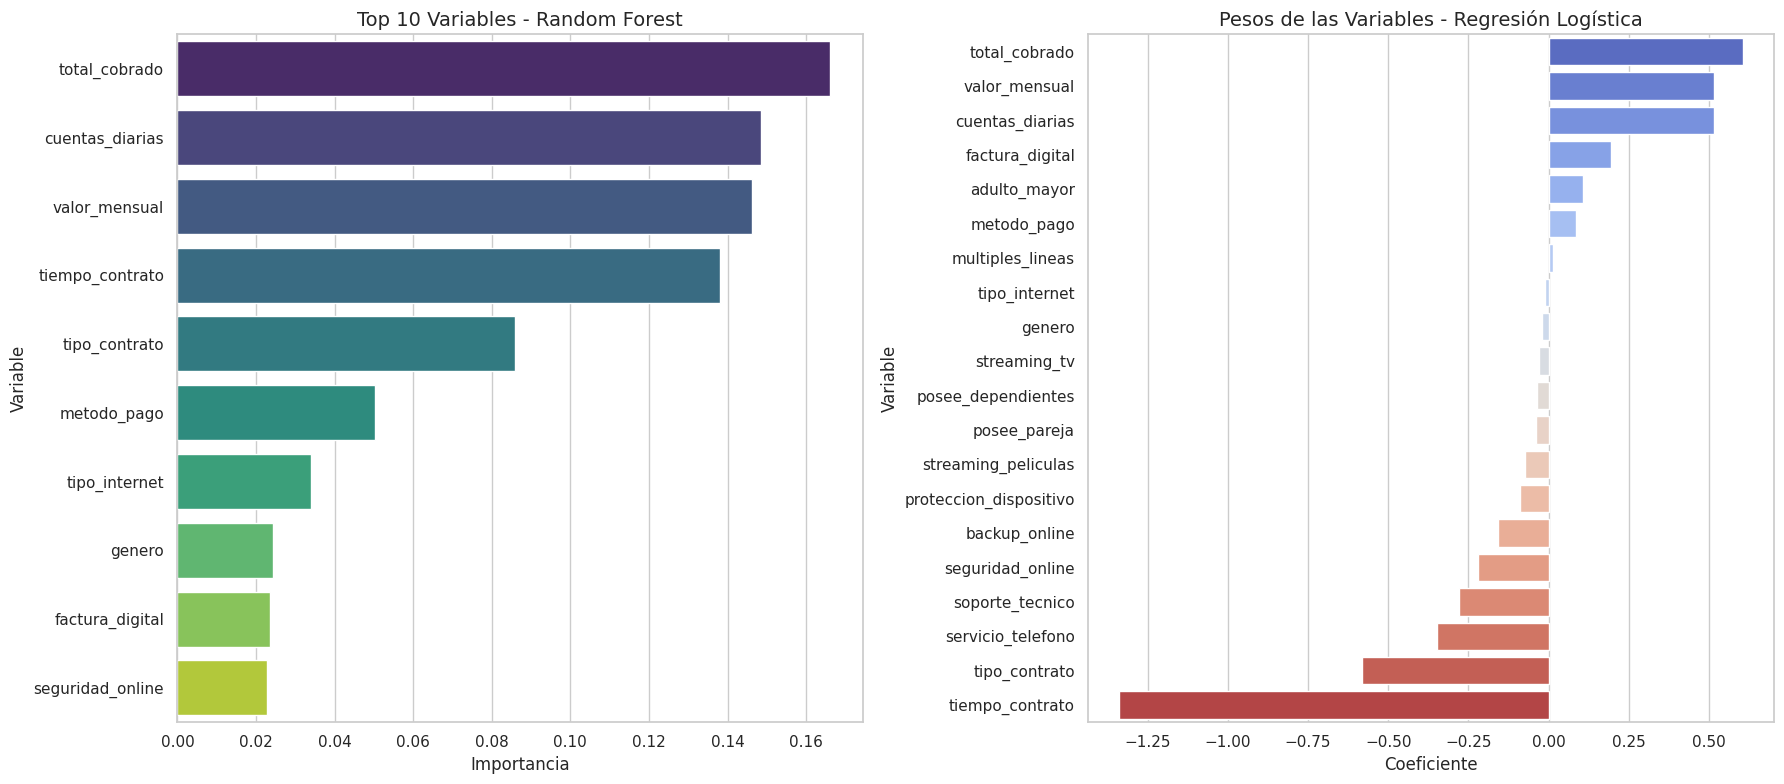

In [43]:
# 1. Extraer Importancia de Random Forest
importancias_rf = modelo_forest.feature_importances_
rf_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias_rf
}).sort_values(by='Importancia', ascending=False)

# 2. Extraer Coeficientes de Regresión Logística
coeficientes = modelo_logistico.named_steps['logisticregression'].coef_[0]
log_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': coeficientes
}).sort_values(by='Coeficiente', ascending=False)

# 3. Visualización Final
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Gráfico RF
sns.barplot(
    ax=axes[0], x='Importancia', y='Variable', data=rf_df.head(10),
    palette='viridis', hue='Variable', legend=False
)
axes[0].set_title('Top 10 Variables - Random Forest', fontsize=14)

# Gráfico Regresión Logística
sns.barplot(
    ax=axes[1], x='Coeficiente', y='Variable', data=log_df,
    palette='coolwarm', hue='Variable', legend=False
)
axes[1].set_title('Pesos de las Variables - Regresión Logística', fontsize=14)

plt.tight_layout()
plt.show()

# **Conclusión - Informe Final**

## **📊 Informe Final: Análisis de Cancelación de Clientes (Churn)**

### **1. Resumen del Rendimiento de los Modelos**

En este proyecto comparamos dos enfoques distintos para predecir qué clientes tienen mayor probabilidad de abandonar la compañía:

* **Regresión Logística:** Fue el modelo más equilibrado. Al ser un modelo lineal, nos permitió entender no solo qué variables importan, sino en qué dirección afectan (si aumentan o disminuyen el riesgo).

* **Random Forest:** Mostró una excelente capacidad para capturar relaciones complejas entre los datos financieros y el tiempo de contrato, sin necesidad de normalizar las escalas.

Métrica de éxito: Priorizamos el Recall (Sensibilidad). En un problema de Churn, es preferible identificar a un cliente que podría irse (aunque al final se quede), que perder a un cliente por no haberlo detectado a tiempo.

### **2. Factores Clave en la Cancelación (Hallazgos)**

Tras analizar la importancia de las variables, identificamos los tres pilares principales que explican por qué un cliente decide cancelar su servicio:

**A. El tipo de contrato:** Es el predictor más fuerte. Los clientes con contratos mes a mes tienen un riesgo de fuga significativamente mayor que aquellos con contratos a largo plazo (1 o 2 años).

**B. Barrera de los 6 meses (Tenure):** Existe una "zona crítica" durante el primer semestre de relación con el cliente. Si un cliente supera los 12 meses de antigüedad, su probabilidad de abandono se reduce drásticamente.

**C. Carga Financiera Mensual:** Los clientes con facturas mensuales más altas, especialmente aquellos vinculados al servicio de fibra óptica, presentan una mayor tasa de cancelación, lo que sugiere una alta sensibilidad al precio en este segmento.

### **3. Estrategias de Retención Propuestas**

Basándonos en la "inteligencia" de los modelos entrenados, proponemos las siguientes acciones comerciales:

**Estrategia 1: Migración de Contratos**

Incentivar a los clientes de "mes a mes" para que cambien a planes anuales. Esto puede lograrse mediante descuentos progresivos: a mayor duración del contrato, menor el costo mensual.

**Estrategia 2: Programa de Bienvenida (Primeros 6 meses)**

Reforzar la atención al cliente durante el primer semestre. Implementar encuestas de satisfacción automatizadas a los 30 y 90 días para resolver problemas técnicos antes de que el cliente considere la cancelación.

**Estrategia 3: Optimización de Valor en Fibra Óptica**

Para los clientes de alto consumo (fibra óptica), ofrecer servicios de valor agregado gratuitos (como servicios de streaming o seguridad online) para aumentar el valor percibido del servicio sin reducir el precio de la factura.

**Estrategia 4: Automatización de Pagos**

Fomentar la factura digital y el pago automático. Los datos indican que los clientes con pagos automatizados tienen una relación más estable y duradera con la empresa.

### **Conclusión**

El uso de Machine Learning en este dataset nos permite dejar de "reaccionar" a las cancelaciones y empezar a "predecirlas". Con un Recall optimizado, el equipo de marketing puede dirigir sus esfuerzos de retención de manera quirúrgica, enfocándose en ese 26% de la base de datos que el modelo ha marcado como de alto riesgo, maximizando así el retorno de inversión en campañas de lealtad.